# 06 — Attention Kernels

Covers Phase 6 of the kernel roadmap — the main goal:
- `naive_attention` — O(N²) memory, baseline
- `sdpa` — scaled dot-product + causal masking
- `multi_head_attention` — head splitting
- `flash_attention_v1` — online softmax, O(N) memory
- `flash_attention_v2` — Q-block parallelism, fewer HBM writes

**Metric**: TFLOPS — `(4 × N² × d × 1e-12) / (ms × 1e-3)`

**References**:
- FlashAttention: https://arxiv.org/abs/2205.14135
- FlashAttention-2: https://arxiv.org/abs/2307.08691

In [5]:
# ── Setup: mount Drive and clone / pull the repo ─────────────────────────────
import os
from google.colab import drive

drive.mount("/content/drive")

REPO_URL    = "https://github.com/Bhavikupadhyay/triton-kernels.git"
REPO_BRANCH = "feature/sdpa"
REPO_DIR    = "/content/drive/MyDrive/triton-kernels"

if os.path.exists(REPO_DIR):
    !git -C {REPO_DIR} fetch --all
    !git -C {REPO_DIR} checkout -f {REPO_BRANCH}
    !git -C {REPO_DIR} reset --hard origin/{REPO_BRANCH}
else:
    !git clone --branch {REPO_BRANCH} {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
!git rev-parse --abbrev-ref HEAD
!bash scripts/setup_colab.sh

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fetching origin
Already on 'feature/naive-attention'
Your branch is up to date with 'origin/feature/naive-attention'.
HEAD is now at 70d0e0f feat: naive attention kernel — O(N²) baseline with online softmax
feature/naive-attention
=== Triton Kernels: Colab Setup ===
[1/4] Installing extra dependencies...
[2/4] Installing kernels package...
  Preparing metadata (setup.py) ... done
[3/4] Verifying GPU...
GPU: Tesla T4
  Memory: 15.6 GB
  SM count: 40
  Compute capability: 7.5
[4/4] Environment report...
Python: 3.12.12
PyTorch: 2.10.0+cu128
Triton: 3.6.0
kernels package: OK

=== Setup complete. Ready to run kernels. ===


In [6]:
# ── Imports ──────────────────────────────────────────────────────────────────
import torch
import triton
from kernels.attention.naive_attention import naive_attention, test_naive_attention, benchmark_naive_attention
from kernels.attention.sdpa import sdpa, test_sdpa, benchmark_sdpa

print("Imports ready")

Imports ready


## 1. naive_attention

**File**: `kernels/attention/naive_attention.py`  
**Formula**: `softmax(Q K^T / sqrt(d)) V`  
**Memory**: O(N²) — materializes the full attention matrix in HBM  
**Serves as**: correctness reference for all subsequent attention kernels

In [7]:
# ── naive_attention: Correctness ─────────────────────────────────────────────
test_naive_attention()

Testing naive_attention...
  N=  64  d= 32  max_err=2.38e-07  PASS
  N=  64  d= 64  max_err=2.38e-07  PASS
  N= 128  d= 32  max_err=2.38e-07  PASS
  N= 128  d= 64  max_err=2.09e-07  PASS
  N= 256  d= 32  max_err=1.79e-07  PASS
  N= 256  d= 64  max_err=2.09e-07  PASS
  N= 512  d= 32  max_err=1.94e-07  PASS
  N= 512  d= 64  max_err=2.38e-07  PASS
All tests passed.


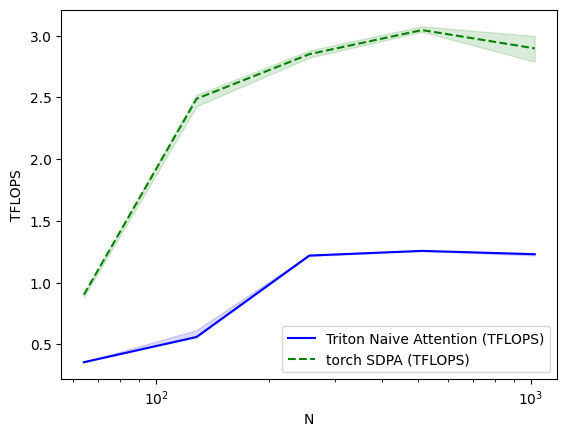

naive_attention_benchmark:
        N  Triton Naive Attention (TFLOPS)  torch SDPA (TFLOPS)
0    64.0                         0.356174             0.902389
1   128.0                         0.560212             2.488463
2   256.0                         1.219274             2.849391
3   512.0                         1.257238             3.044867
4  1024.0                         1.230449             2.896619


<Figure size 640x480 with 0 Axes>

In [8]:
# ── naive_attention: Benchmark ───────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/attention", exist_ok=True)

benchmark_naive_attention.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/attention",
)

**Triton runs at 40–43% of torch SDPA at large N, with both implementations plateauing around N=256.**

**N=64–128 — kernel launch overhead and low occupancy.** Both providers are far below their compute ceiling. At N=64 the total flop count (4·1·1·64²·64 = 1.07 GFLOPs) is tiny; launch latency and tensor setup dominate. Triton: 0.36–0.56 TFLOPS; torch: 0.90–2.49 TFLOPS.

**N=256–1024 — compute bound, consistent gap.** Triton holds steady at 1.22–1.26 TFLOPS; torch at 2.85–3.04 TFLOPS — roughly 2.4× apart throughout. Both have hit the throughput ceiling for their respective matmul implementations. The flat TFLOPS means efficiency per FLOP is constant, not degrading.

The 2.4× gap reflects two things: torch SDPA dispatches to cuBLAS for QKᵀ and scores·V, which uses wider tiles and hardware-tuned instruction scheduling; this kernel uses `tl.dot` with BLOCK_N=32, limiting tile reuse and occupancy. This baseline exists to establish the O(N²) cost curve — the reference point for Flash Attention's memory reduction.

## 2. sdpa

**File**: `kernels/attention/sdpa.py`  
**Adds**: Causal masking (decoder attention)

In [ ]:
# ── sdpa: Correctness ────────────────────────────────────────────────────────
test_sdpa()

In [ ]:
# ── sdpa: Benchmark ──────────────────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/attention", exist_ok=True)

benchmark_sdpa.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/attention",
)

**Interpretation**: Add notes here.

## 3. multi_head_attention

**File**: `kernels/attention/multi_head_attention.py`  
**Adds**: Head splitting via `tl.program_id(1)` for the head axis

In [ ]:
# ── multi_head_attention: Correctness ────────────────────────────────────────
# test_multi_head_attention()

In [ ]:
# ── multi_head_attention: Benchmark ──────────────────────────────────────────
# benchmark_multi_head_attention.run(print_data=True, show_plots=True,
#     save_path="benchmarks/results/attention/multi_head_attention_benchmark.png")

**Interpretation**: Add notes here.

## 4. flash_attention_v1

**File**: `kernels/attention/flash_attention_v1.py`  
**Key**: Online softmax trick — accumulates max/sum across K,V tiles so the full N×N matrix never materializes. O(N) memory.
**Reference**: Dao et al. 2022 — https://arxiv.org/abs/2205.14135

In [ ]:
# ── flash_attention_v1: Correctness ──────────────────────────────────────────
# test_flash_attention_v1()

In [ ]:
# ── flash_attention_v1: Benchmark ────────────────────────────────────────────
# benchmark_flash_attention_v1.run(print_data=True, show_plots=True,
#     save_path="benchmarks/results/attention/flash_attention_v1_benchmark.png")

**Interpretation**: Add notes here.

## 5. flash_attention_v2

**File**: `kernels/attention/flash_attention_v2.py`  
**Key improvements over v1**:
- Parallelism over Q blocks (not just K,V)
- Fewer HBM writes
- Better occupancy via rearranged outer loop

**Reference**: Dao 2023 — https://arxiv.org/abs/2307.08691

In [ ]:
# ── flash_attention_v2: Correctness ──────────────────────────────────────────
# test_flash_attention_v2()

In [ ]:
# ── flash_attention_v2: Benchmark ────────────────────────────────────────────
# benchmark_flash_attention_v2.run(print_data=True, show_plots=True,
#     save_path="benchmarks/results/attention/flash_attention_v2_benchmark.png")

**Interpretation**: Add notes here.

In [ ]:
# ── Summary Table ────────────────────────────────────────────────────────────
# import pandas as pd, glob
# csvs = glob.glob("benchmarks/results/attention/*.csv")
# if csvs:
#     print(pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True).to_string(index=False))
# else:
#     print("No CSVs yet.")